In [15]:
import rebound
import numpy as np
from tqdm import tqdm
from scipy import signal
import matplotlib.pyplot as plt

In [11]:
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

def hk_ft(times,pomega,ecc):
    h = ecc*np.sin(pomega)
    f,pxx = ft(times, h)
    return f,pxx

def ecc_ft(times,ecc):
    f,pxx = ft(times, ecc)
    return f,pxx

In [18]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=0,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    long_peri_j[i] = sim.particles[1].pomega
    e_j[i] = sim.particles[1].e

f,pxx = pomega_ft(times, long_peri_sat, e_sat)

100%|██████████████████████████████████████████████████████████████████████████| 100000/100000 [04:50<00:00, 344.08it/s]


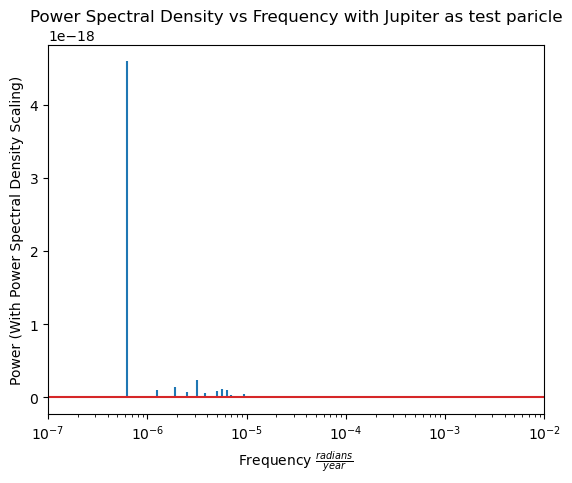

In [19]:
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency with Jupiter as test paricle')
plt.show()

100%|██████████████████████████████████████████████████████████████████████████| 100000/100000 [04:53<00:00, 340.35it/s]


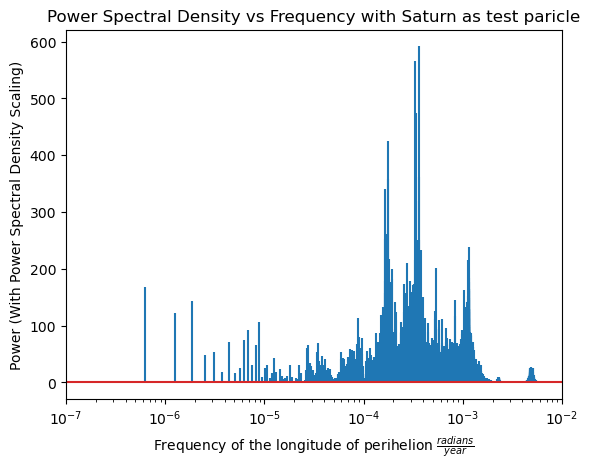

In [20]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=0,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    long_peri_j[i] = sim.particles[1].pomega
    e_j[i] = sim.particles[1].e

f,pxx = pomega_ft(times, long_peri_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency with Saturn as test paricle')
plt.show()